## Forecasting CO2 levels on Mona Loa dataset using Gaussian Process regression (GPR)

This is an excerpt from Gaussian Processes for Machine Learning. It breaks down kernel engineering and hyperparameter optimization using gradient ascent on the log-marginal-likelihood. 

About the dataset: It consists of monthly average atmospheric CO2 concentrations collected in the Mauna Loa Observatory in Hawaii between 1958 and 2001. 

To model: CO2 concentration 

Function: function of time t

To do: extrapolate for years after 2001.

# Build the dataset

In [2]:
from sklearn.datasets import fetch_openml

co2 = fetch_openml(data_id=41187, as_frame=True)
co2.frame.head()

,year,month,day,weight,flag,station,co2
0,1958,3,29,4,0,MLO,316.1
1,1958,4,5,6,0,MLO,317.3
2,1958,4,12,4,0,MLO,317.6
3,1958,4,19,6,0,MLO,317.5
4,1958,4,26,2,0,MLO,316.4


Process the original dataframe to create a date column and select it along with the CO2 column.

In [3]:
import polars as pl

co2_data = pl.DataFrame(co2.frame[["year", "month", "day", "co2"]]).select(
    pl.date("year", "month", "day"), "co2"
)
co2_data.head()

date,co2
date,f64
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [4]:
co2_data["date"].min(), co2_data["date"].max()

(datetime.date(1958, 3, 29), datetime.date(2001, 12, 29))

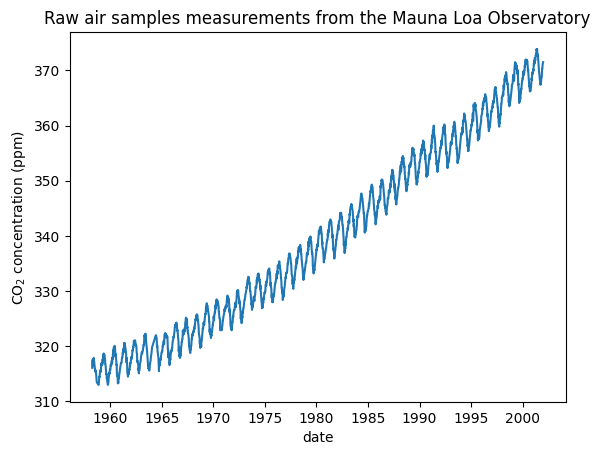

In [5]:
import matplotlib.pyplot as plt

plt.plot(co2_data["date"], co2_data["co2"])
plt.xlabel("date")
plt.ylabel("CO$_2$ concentration (ppm)")
_ = plt.title("Raw air samples measurements from the Mauna Loa Observatory")

Preprocess the dataset by taking a monthly average and drop months for which no measurements were collected. Such a processing will have a smoothing effect on the data.

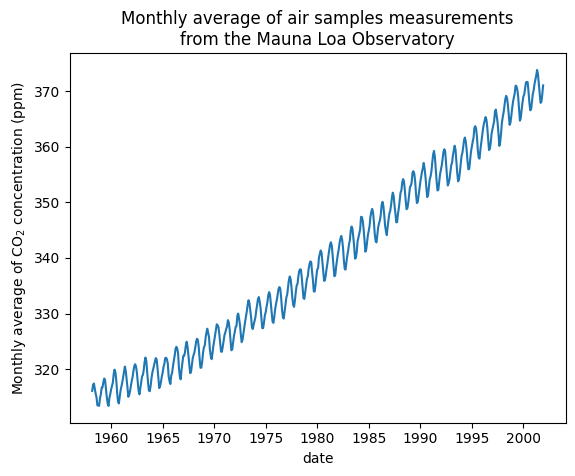

In [6]:
co2_data = (
    co2_data.sort(by="date")
    .group_by_dynamic("date", every="1mo")
    .agg(pl.col("co2").mean())
    .drop_nulls()
)
plt.plot(co2_data["date"], co2_data["co2"])
plt.xlabel("date")
plt.ylabel("Monthly average of CO$_2$ concentration (ppm)")
_ = plt.title(
    "Monthly average of air samples measurements\nfrom the Mauna Loa Observatory"
)

As a first step, we will divide the data and the target to estimate. The data being a date, we will convert it into a numeric.

In [7]:
X = co2_data.select(
    pl.col("date").dt.year() + pl.col("date").dt.month() / 12
).to_numpy()
y = co2_data["co2"].to_numpy()

## Design the proper kernel


To begin with, we will make some assumptions about the dataset. There is a long term rising trend to the data, the dips we see are seasonal changes captured in the data and smaller changes or irregularities. We need to pick a kernel based on everything that we have assumed about the dataset. These patterns seem independent so 1 kernel cannot do all the work. We will handle each of these separately and take the sum at the end. 

1. The first assumption which is the long term rising trend can be fitted using a radial basis function (RBF) kernel with the length scale parameter as 50. A length-scale that large means points decades apart are still treated as related, so there's no room for the curve to zigzag. This approach will ensure this component to be smooth. The length-scale and the amplitude are hyperparameters, they are the degrees of freedom the optimiser will tune when it fits the model. 

Here's why a large length-scale forces this kind of smoothness. The RBF kernel's formula is:

$$k(x, x') = \sigma^2 \exp\left(-\frac{(x-x')^2}{2\ell^2}\right)$$

$k(x, x')$ is the covariance between the function's value at two points which is basically how strongly the model believes they should move together. When two points are close together relative to $\ell$, the exponent stays near zero, so $k(x,x')$ stays close to its maximum and the two points are forced to move almost in lockstep. When two points are far apart relative to $\ell$, the exponent becomes a large negative number and $k(x,x')$ collapses toward zero, meaning the model treats them as essentially unrelated.

Our dataset spans about 44 years, so plugging the largest possible gap into the formula with $\ell = 50$ shows how strongly connected even the most distant points still are:

$$\frac{(44)^2}{2(50)^2} = \frac{1936}{5000} \approx 0.387 \quad \Rightarrow \quad \exp(-0.387) \approx 0.68$$

Even the two points furthest apart in the entire dataset still retain about 68% of the maximum possible covariance. That's the actual mathematical reason nothing in the data can bend back down within the observed window, the length-scale is large enough that the kernel treats the whole 44-year span as still meaningfully connected, not just nearby points.

In [8]:
from sklearn.gaussian_process.kernels import RBF

long_term_trend_kernel = 50.0**2 * RBF(length_scale=50.0)


2. A purely periodic kernel will force it to look like the same pattern is present every year forever which is not true as we can see. We handle this by multiplying the RBF so the pattern will still repeat every year but its allowed to change its shape over the years. This seasonal variation is captured by the periodic exponential sine squared kernel with a fixed periodicity of 1 year. Here the RBF's length scale controls the decay time and is another free parameter which is separate from the periodic kernel's own length scale, which controls the shape of each yearly wave. This is also known as the $\textit{locally periodic kernel.}$

In [9]:
from sklearn.gaussian_process.kernels import ExpSineSquared

seasonal_kernel = (
    2.0**2
    * RBF(length_scale=100.0)
    * ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds="fixed")
)

3. The smaller irregularities can be explained by a rational quadratic kernel component. The rational quadratic kernel is different to the RBF kernel because it explains several length-scales and will accommodate more and different irrehularities. The alpha controls how much mixing happens so a smaller alpha means blending a wide spread of length scales and a large alpha will make it collapse towards behaving like a single length RBF. We take a mixture because some irregularities are short and some stretch out for longer.

In [10]:
from sklearn.gaussian_process.kernels import RationalQuadratic

irregularities_kernel = 0.5**2 * RationalQuadratic(length_scale=1.0, alpha=1.0)

The noise in the dataset comes in two different forms, and one kernel can't explain both. Some of it is correlated over short stretches, local weather patterns nudging several consecutive readings in the same direction for a few weeks — and that gets picked up by an RBF kernel with a small length-scale. The rest is plain white noise, with no relationship from one point to the next, which the WhiteKernel accounts for. The relative amplitudes and the RBF's length-scale are further free parameters, so the model captures both the correlated changes and the pure randomness.

In [11]:
from sklearn.gaussian_process.kernels import WhiteKernel

noise_kernel = 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(
    noise_level=0.1**2, noise_level_bounds=(1e-5, 1e5)
)

Thus, our final kernel is an addition of all previous kernel.

In [12]:
co2_kernel = (
    long_term_trend_kernel + seasonal_kernel + irregularities_kernel + noise_kernel
)
co2_kernel

50**2 * RBF(length_scale=50) + 2**2 * RBF(length_scale=100) * ExpSineSquared(length_scale=1, periodicity=1) + 0.5**2 * RationalQuadratic(alpha=1, length_scale=1) + 0.1**2 * RBF(length_scale=0.1) + WhiteKernel(noise_level=0.01)

## Model fitting and extrapolation

Now, we are ready to use a Gaussian process regressor and fit the available data. To follow the example from the literature, we will subtract the mean from the target. We could have used normalize_y=True. However, doing so would have also scaled the target (dividing y by its standard deviation). Thus, the hyperparameters of the different kernel would have had different meaning since they would not have been expressed in ppm.

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor

y_mean = y.mean()
gaussian_process = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False)
gaussian_process.fit(X, y - y_mean)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",50**2 * RBF(l...se_level=0.01)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",0
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

Now, we will use the Gaussian process to predict on:

- training data to inspect the goodness of fit;

- future data to see the extrapolation done by the model.

Thus, we create synthetic data from 1958 to the current month. In addition, we need to add the subtracted mean computed during training.

import

In [14]:
import datetime

import numpy as np

today = datetime.datetime.now()
current_month = today.year + today.month / 12
X_test = np.linspace(start=1958, stop=current_month, num=1_000).reshape(-1, 1)
mean_y_pred, std_y_pred = gaussian_process.predict(X_test, return_std=True)
mean_y_pred += y_mean

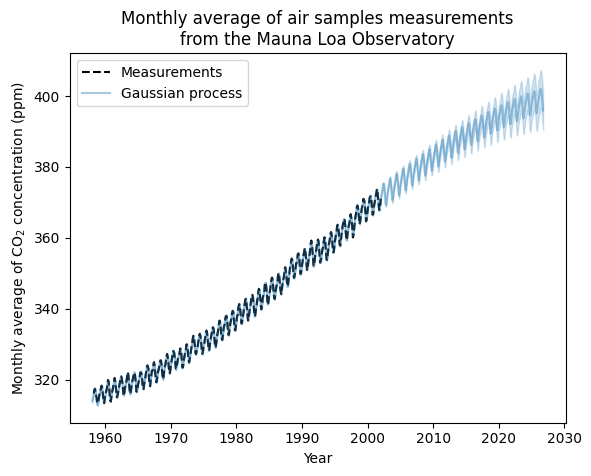

In [15]:
plt.plot(X, y, color="black", linestyle="dashed", label="Measurements")
plt.plot(X_test, mean_y_pred, color="tab:blue", alpha=0.4, label="Gaussian process")
plt.fill_between(
    X_test.ravel(),
    mean_y_pred - std_y_pred,
    mean_y_pred + std_y_pred,
    color="tab:blue",
    alpha=0.2,
)
plt.legend()
plt.xlabel("Year")
plt.ylabel("Monthly average of CO$_2$ concentration (ppm)")
_ = plt.title(
    "Monthly average of air samples measurements\nfrom the Mauna Loa Observatory"
)

# Interpretation of kernel hyperparameters

In [16]:
gaussian_process.kernel_

44.8**2 * RBF(length_scale=51.6) + 2.64**2 * RBF(length_scale=91.5) * ExpSineSquared(length_scale=1.48, periodicity=1) + 0.536**2 * RationalQuadratic(alpha=2.89, length_scale=0.968) + 0.188**2 * RBF(length_scale=0.122) + WhiteKernel(noise_level=0.0367)

- trend: amplitude: 44.8 ppm, length-scale: 51.6 years. Amplitude shows how much trend swings overall and the length-scale being that large means the model sees this as one long climb. Thus, nothing in the data looks like it could bend back down within the observation.

- Seasonal trend: amplitude: 2.64 ppm, which is the yearly up and down zig-zag in real ppm. RBF decay length is about 91.5 years, which is longer than the whole dataset, so the seasonal shape barely drifts or changes over the years. The pattern stays almost exactly periodic instead of morphing.

- Irregularities: amplitude: 0.536 ppm, alpha: 2.89. The leftover irregularites are not major contributors to the trend over time. Alpha not being tiny means its not blending a huge spread of length-scales but a moderate mix.

- Noise: correlated part has amplitude 0.188 ppm over a length-scale of 0.122 years, and the white noise level is 0.0367 (a variance), which is about 0.19 ppm of pure random jitter. Both are small next to the 44.8 ppm trend and ~2.64 ppm seasonal amplitudes. This means the structural kernels are explaining almost all the real variation in the data, and not much is being left over as unexplained randomness.

## Gap experiment

In [17]:
# Limitation experiment: hide a 15-year stretch (1975-1990) and see how
# the model reconstructs it and how confident it says it is
gap_start, gap_end = 1975.0, 1990.0
mask = ~((X[:, 0] >= gap_start) & (X[:, 0] < gap_end))

X_gap, y_gap = X[mask].reshape(-1, 1), y[mask]
X_removed, y_removed = X[~mask].reshape(-1, 1), y[~mask]

y_mean_gap = y_gap.mean()
gp_gap = GaussianProcessRegressor(kernel=co2_kernel, normalize_y=False, n_restarts_optimizer=3)
gp_gap.fit(X_gap, y_gap - y_mean_gap)

/Users/anjan/Downloads/nb_env/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",50**2 * RBF(l...se_level=0.01)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",3
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`G

In [18]:
X_test_gap = np.linspace(1958, 2002, 2000).reshape(-1, 1)
mean_pred_gap, std_pred_gap = gp_gap.predict(X_test_gap, return_std=True)
mean_pred_gap += y_mean_gap

in_gap = (X_test_gap[:, 0] >= gap_start) & (X_test_gap[:, 0] < gap_end)
print("Avg predictive std inside the gap:", std_pred_gap[in_gap].mean())
print("Avg predictive std outside the gap:", std_pred_gap[~in_gap].mean())

interp_mean = np.interp(X_removed[:, 0], X_test_gap[:, 0], mean_pred_gap)
resid = y_removed - interp_mean
print("Mean abs error on the hidden years:", np.abs(resid).mean())
print("Max abs error on the hidden years:", np.abs(resid).max())

Avg predictive std inside the gap: 0.6495413345574491
Avg predictive std outside the gap: 0.22337561402037126
Mean abs error on the hidden years: 0.3848817282022613
Max abs error on the hidden years: 1.3992842571803408


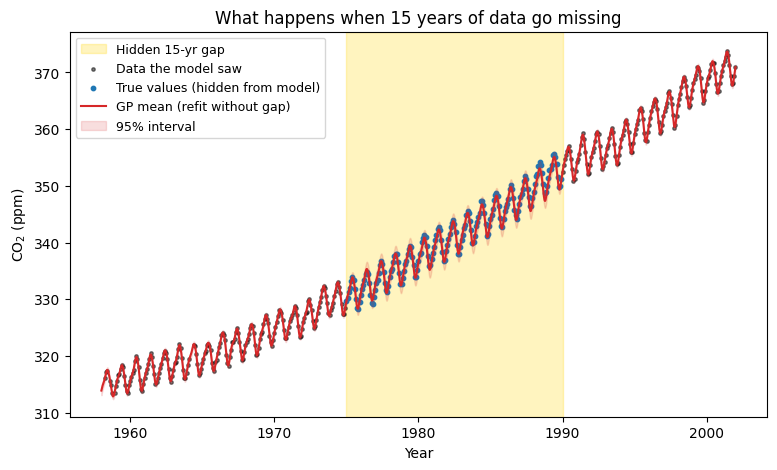

In [19]:
plt.figure(figsize=(9, 5))
plt.axvspan(gap_start, gap_end, color="gold", alpha=0.25, label="Hidden 15-yr gap")
plt.scatter(X_gap, y_gap, s=6, color="black", alpha=0.5, label="Data the model saw")
plt.scatter(X_removed, y_removed, s=10, color="tab:blue", label="True values (hidden from model)")
plt.plot(X_test_gap, mean_pred_gap, color="tab:red", label="GP mean (refit without gap)")
plt.fill_between(
    X_test_gap.ravel(),
    mean_pred_gap - 2 * std_pred_gap,
    mean_pred_gap + 2 * std_pred_gap,
    color="tab:red", alpha=0.15, label="95% interval",
)
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.title("What happens when 15 years of data go missing")
plt.legend(loc="upper left", fontsize=9)

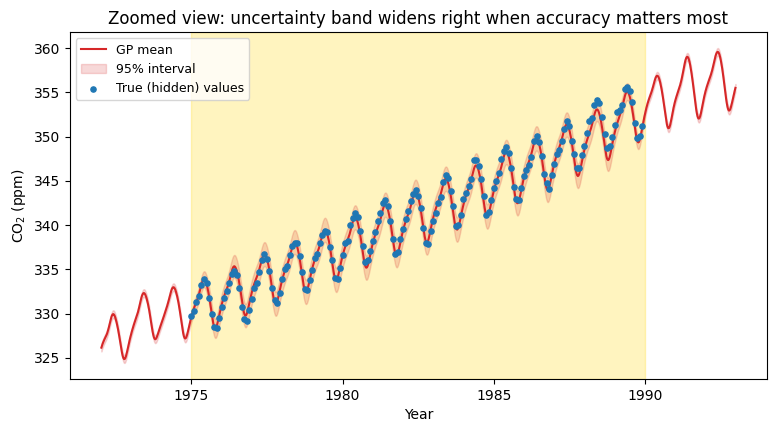

In [21]:
# Zoomed view: focus on the gap itself, ±3 years padding
zoom_mask_test = (X_test_gap[:, 0] > gap_start - 3) & (X_test_gap[:, 0] < gap_end + 3)
zoom_mask_removed = (X_removed[:, 0] > gap_start - 3) & (X_removed[:, 0] < gap_end + 3)

plt.figure(figsize=(9, 4.5))
plt.axvspan(gap_start, gap_end, color="gold", alpha=0.25)
plt.plot(X_test_gap[zoom_mask_test], mean_pred_gap[zoom_mask_test], color="tab:red", label="GP mean")
plt.fill_between(
    X_test_gap[zoom_mask_test, 0],
    (mean_pred_gap - 2 * std_pred_gap)[zoom_mask_test],
    (mean_pred_gap + 2 * std_pred_gap)[zoom_mask_test],
    color="tab:red", alpha=0.18, label="95% interval",
)
plt.scatter(X_removed[zoom_mask_removed], y_removed[zoom_mask_removed], s=14, color="tab:blue", label="True (hidden) values", zorder=5)
plt.xlabel("Year")
plt.ylabel("CO$_2$ (ppm)")
plt.title("Zoomed view: uncertainty band widens right when accuracy matters most")
plt.legend(loc="upper left", fontsize=9)

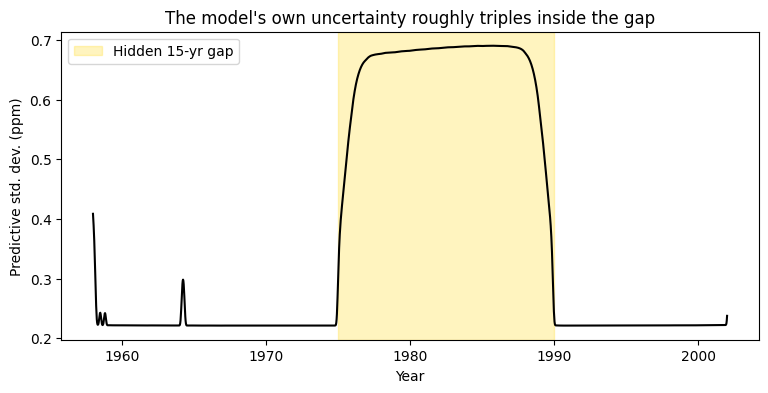

In [20]:
plt.figure(figsize=(9, 4))
plt.axvspan(gap_start, gap_end, color="gold", alpha=0.25, label="Hidden 15-yr gap")
plt.plot(X_test_gap, std_pred_gap, color="black")
plt.xlabel("Year")
plt.ylabel("Predictive std. dev. (ppm)")
plt.title("The model's own uncertainty roughly triples inside the gap")
plt.legend(loc="upper left")

## Limitation: what happens with a multi-year gap in the data

To test this, we hid 15 years of data (1975-1990) and refit the same kernel on the rest. Then we checked how well it filled in the missing years and how sure it was about it.

The mean prediction stayed close to the real values even with 15 years missing. Mean absolute error was about 0.38 ppm, worst case 1.40 ppm. But the predictive uncertainty roughly tripled inside the gap, going from about 0.22 ppm outside it to 0.65 ppm inside, then dropped back down as soon as real data started again.

This makes sense because of how the kernel is built. The trend and seasonal kernels are strong enough that the model can coast through a gap using structure alone, it already assumes CO2 rises steadily and repeats every year, so it doesn't really need to see the missing years to guess them. What it can't do is stay confident without real data there, so the uncertainty goes up even though the guess is still decent.

This is also where the limitation shows up. A 15 year gap is small enough for the trend and seasonal kernels to bridge. A much bigger gap, or a period where the trend wasn't as steady, would eventually break the mean prediction too and not just the uncertainty. The model would still draw a smooth confident-looking curve through it, it just wouldn't actually know if reality stayed that smooth.